# Computational Set: Data Analysis A — Linear Regression

### Calibration of a Pressure Gauge

**Learning objectives**

- Fit a linear data set $y = mx + b$ and extract the slope and intercept *together with their uncertainties*.
- Plot data and the regression line and judge the quality of a linear fit.
- Report parameters and uncertainties with correct units and significant figures.

---

#### Background

How do we know a gauge reads the correct value? We *calibrate* it against a known standard. Here a **capsule vacuum gauge** is calibrated against a **closed-end mercury manometer**, which we treat as the true pressure after a small correction for the thermal expansion of mercury:

$$
P(\text{Torr}) = P_{\text{obs}}\,\bigl(1 - 1.8\times10^{-4}\,T\bigr), \qquad T \text{ in } {}^{\circ}\mathrm{C}. \tag{1}
$$

*Note: the original lab handout's Eq. 1 had a typo — the raw quantity being corrected was left blank ("$P()$"). Here $P_{\text{obs}}$ denotes the raw mercury height difference $h_{\text{left}} - h_{\text{right}}$ (mm Hg, numerically equal to Torr before correction), consistent with the step-by-step instructions elsewhere in the handout.*

The gauge response should be **linear** in pressure up to atmospheric pressure, so we model

$$
P = m\,P_{\text{gauge}} + b. \tag{2}
$$

In Excel you may have used the *Regression* tool to get $m$, $b$, and their standard deviations $S_m$, $S_b$. Here we do the same thing in Python with `numpy.polyfit`, which returns both the best-fit parameters **and** their covariance matrix — the square roots of its diagonal are exactly those standard deviations.


## New to Python? Start here

You don't need prior programming experience for this set. Almost everything below is
"fill in a short expression" using a handful of patterns. Here's all the syntax you'll need:

- **Comments.** Anything after a `#` is a note for humans; Python ignores it. The blanks you
  complete are marked with a comment like `# <-- replace with your expression`.

- **Variables.** `x = 5` stores the value `5` under the name `x`. Names are case-sensitive
  (`T` and `t` are different) and must be defined before you use them. Run cells **top to
  bottom** so each variable exists when later cells need it.

- **Arithmetic.** `+  -  *  /` work as expected, and `**` is *exponent* (so `x**2` is $x^2$).

- **Data Types** `int` are integers (counting numbers), `float` are floating point numbers (numbers with decimal places, `str` are strings of characters (which can include numbers, letters, or other symbols).

- **Arrays (NumPy).** Our data lives in `np.array([...])`. The big convenience: arithmetic
  acts on the **whole array at once**. If `a` and `b` are arrays, `a - b` subtracts them
  element by element — no loop needed. Write the formula as if `a` and `b` were single numbers.

- **Calling a function.** A function takes inputs (*arguments*) in parentheses and often hands
  back a result you can store: `result = some_function(input1, input2)`. A function can return
  more than one value at once, which you catch with a comma: `a, b = gives_two_things()`.

- **Seeing output.** `print(...)` displays values so you can check your work.

> 💡 Want a proper, gentle introduction first? Work through the ESCIP
> **[“What is Python?” notebook](https://escip.io/notebooks/python/python-basics-fixed.html)**
> — it covers variables, functions, lists, and more, with chemistry examples. Highly
> recommended if any of the above is unfamiliar.

---



## The data

A run of the calibration produced, at each step:

- `P_dial` — the vacuum-gauge dial reading (inHg, read to 0.1 inHg),
- `h_left`, `h_right` — the left and right mercury meniscus positions, each recorded as a
  *displacement from a common zeroed reference* (mm), not as independent absolute heights.
  One arm moves positive, the other negative, as pressure is admitted.

together with the barometric pressure `P_atm_inHg` and the manometer temperature `T_C`.

Run the cell below to load the data — **you don't need to edit it.**

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Experimental constants ---
P_atm_inHg = 31.20     # barometric (atmospheric) pressure, inHg
T_C        = 21.5      # manometer temperature, degrees C

# --- Raw readings (one row per step) ---
# A small, real subset of a run (from an instructor-provided data set), used to illustrate
# the array operations below. Note the convention: h_left and h_right are each measured as a
# *displacement from a common zero* (both start at 0), not as independent absolute heights --
# one arm reads positive, the other negative, as pressure is admitted.
P_dial  = np.array([26.4, 22.1, 17.2, 12.8, 8.1, 4.4])            # inHg
h_left  = np.array([0.0, 62.0, 122.0, 182.0, 242.0, 289.0])       # mm, displacement from zero
h_right = np.array([0.0, -61.0, -122.0, -181.0, -242.0, -289.0])  # mm, displacement from zero

print(f"{len(P_dial)} data points loaded.")
print("P_dial  (inHg):", P_dial)
print("h_left  (mm)  :", h_left)
print("h_right (mm)  :", h_right)

6 data points loaded.
P_dial  (inHg): [26.4 22.1 17.2 12.8  8.1  4.4]
h_left  (mm)  : [  0.  62. 122. 182. 242. 289.]
h_right (mm)  : [   0.  -61. -122. -181. -242. -289.]


## Step 1 — Build the derived columns

In Excel you computed two new columns; here you build two NumPy arrays. NumPy applies an
arithmetic expression to every element of an array at once, so there is no need for a loop —
write the formula as if `P_dial`, `h_left`, and `h_right` were single numbers.

**The gauge pressure** (this will be the *x* data) is how far the true pressure sits above
the manifold's near-zero baseline, found by subtracting the dial reading from atmospheric
pressure, in inHg.

**The true pressure** (the *y* data) comes from the manometer. In a closed-end manometer the
pressure equals the *difference in height* of the two mercury columns. That raw height
difference is then scaled by the thermal-expansion factor of Eq. (1) to give a result in Torr.

👉 **Your task:** translate those two sentences into array expressions where indicated.


In [6]:
# Thermal-expansion correction factor for mercury (the parenthesis in Eq. 1)
therm = 1 - 1.8e-4 * T_C

# x data, in inHg:  atmospheric pressure  -  dial reading
P_gauge =  P_atm_inHg - P_dial                # <-- replace with your expression

# y data, in Torr:  |height difference between the two mercury columns|  scaled by  therm
P_torr =  therm * np.abs(h_left - h_right)                 # <-- replace with your expression

print("P_gauge (inHg):", np.round(P_gauge, 2))
print("P_torr  (Torr):", np.round(P_torr, 1))

P_gauge (inHg): [ 4.8  9.1 14.  18.4 23.1 26.8]
P_torr  (Torr): [  0.  122.5 243.1 361.6 482.1 575.8]


## Step 2 — Plot the data

Always look at the data before fitting, so you can judge whether a straight line is even
appropriate. We want an XY scatter plot of gauge pressure (horizontal axis) against true
pressure (vertical axis), drawn as **open markers with no connecting line**.

Matplotlib reminder: `ax.plot(x, y, 'o', mfc='none')` draws open circles; the third argument
is a *format string* (`'o'` = circles, `'-'` = a solid line).

👉 **Your task:** supply the `ax.plot(...)` call that draws the data points.


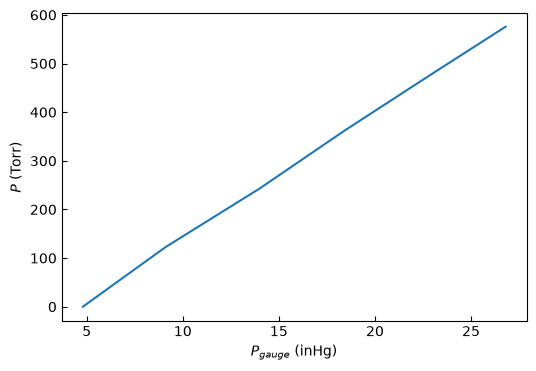

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

# Draw the gauge pressure (x) against the true pressure (y) as open circles, no line.
ax.plot(P_gauge, P_torr                   )   # <-- pass x data, y data, and the format string

ax.set_xlabel('$P_{gauge}$ (inHg)')
ax.set_ylabel('$P$ (Torr)')
ax.tick_params(direction='in')
plt.show()

## Working with your real data

The small set above is easy to type by hand so you can get a feel for how the arrays work.
Now let's repeat the same analysis on your actual experimental run.

**Expected format.** Opened as a spreadsheet, your CSV should look like this (the loader below
reads the atmospheric pressure and temperature from these exact positions, so keep the layout
intact when you export from Excel):

```
Pdial (inHg),left (cm),right (cm),,Patm =,31.20,inHg
26.4,0,0,,T =,21.5,°C
25.2,18,-17,,,,
24.1,32,-31,,,,
...
```

- **Column 1** — the vacuum-gauge dial reading, `P_dial`.
- **Columns 2–3** — the left and right mercury meniscus heights.
- **To the right of the first two rows** — the atmospheric pressure (`Patm =`) and manometer
  temperature (`T =`), each followed by its value and unit.

⚠️ **Check your units before trusting the dropdown.** The sample file's own header says
"(cm)", but the lab write-up's procedure says heights are read *"to the nearest mm,"* and
values on the order of a few hundred **millimeters** are physically reasonable for this
apparatus (a few hundred **centimeters** — multiple meters — would not be). If your CSV's
header also says "cm" but the numbers look mm-scale, leave the dropdown on `mm` rather than
switching it, or check with your instructor which is correct — selecting the wrong option
silently scales every height by 10×.


💾 **Run the cell below to load the data — you don't need to edit it.**
Run the cell below, click **Upload CSV**, and choose your file. If your heights were recorded in
**cm** rather than **mm**, switch the **Height units** dropdown to `cm` — the next cell will
convert them automatically.

**Important:** the cell after the uploader *overwrites* `P_dial`, `h_left`, `h_right`,
`P_atm_inHg`, and `T_C` with your uploaded data. Once it's run, scroll back up and re-run the
**Step 1** and **Step 2** cells above so `P_gauge`, `P_torr`, and the plot are rebuilt from your
real data — then continue on to Step 3 below.

In [8]:
from ipywidgets import FileUpload, Dropdown, VBox
from IPython.display import display

uploader = FileUpload(accept='.csv', multiple=False, description='Upload CSV')
unit_dd  = Dropdown(options=['mm', 'cm'], value='mm', description='Height units:')

display(VBox([uploader, unit_dd]))

# 📥 Run the cell below to load your data - **you don't need to edit it.**

In [9]:
# Run this cell AFTER you've uploaded your file above.
# This OVERWRITES the hand-entered P_dial, h_left, h_right, P_atm_inHg, and T_C
# with your real data (re-run it any time you upload a new file).
import io
import pandas as pd

if len(uploader.value) == 0:
    raise ValueError("No file uploaded yet — click 'Upload CSV' above, choose your file, then re-run this cell.")

# ipywidgets FileUpload.value is a tuple of dicts (v8+) or a dict keyed by filename (v7)
uploaded = uploader.value[0] if isinstance(uploader.value, tuple) else list(uploader.value.values())[0]
raw = pd.read_csv(io.BytesIO(bytes(uploaded['content'])), header=None)

# --- First three columns: Pdial, left, right ---
data = raw.iloc[1:, 0:3].reset_index(drop=True).astype(float)
data.columns = raw.iloc[0, 0:3].tolist()

P_dial  = data.iloc[:, 0].values
h_left  = data.iloc[:, 1].values
h_right = data.iloc[:, 2].values

# --- Convert heights to mm if they were recorded in cm ---
if unit_dd.value == 'cm':
    h_left  = h_left * 10
    h_right = h_right * 10

# --- Metadata: atmospheric pressure and temperature, read from fixed positions ---
P_atm_inHg = float(raw.iloc[0, 5])   # value next to 'Patm ='
T_C        = float(raw.iloc[1, 5])   # value next to 'T ='

print(f"{len(P_dial)} data points loaded from file.")
print(f"P_atm = {P_atm_inHg} inHg,  T = {T_C} °C")
print("P_dial :", P_dial)
print("h_left (mm):", np.round(h_left, 2))
print("h_right (mm):", np.round(h_right, 2))

24 data points loaded from file.
P_atm = 31.2 inHg,  T = 21.5 °C
P_dial : [26.4 25.2 24.1 23.2 22.1 20.7 19.6 18.5 17.2 16.1 14.9 13.8 12.8 11.6
 10.5  9.5  8.1  6.9  5.7  5.   4.4  3.5  2.2  0.2]
h_left (mm): [  0.  18.  32.  47.  62.  78.  94. 107. 122. 137. 153. 168. 182. 197.
 211. 226. 242. 257. 272. 282. 289. 302. 316. 331.]
h_right (mm): [   0.  -17.  -31.  -46.  -61.  -77.  -93. -106. -122. -136. -152. -167.
 -181. -197. -211. -226. -242. -256. -272. -282. -289. -302. -316. -331.]


## Step 3 — Linear regression with uncertainties

`numpy.polyfit(x, y, deg, cov=True)` returns two things: the best-fit coefficients **and** the
covariance matrix of those coefficients.

- For a straight line use degree `deg = 1`.
- The coefficients come back **highest power first**, so the returned pair is
  `[slope, intercept]`.
- The standard deviations $S_m$ and $S_b$ are the **square roots of the diagonal** of the
  covariance matrix. `np.diag(cov)` pulls out that diagonal as an array.

👉 **Your task:** run the fit and pull out the two standard deviations.


In [ ]:
# Fit a degree-1 polynomial of the true pressure (y) on the gauge pressure (x),
# asking polyfit to also return the covariance matrix.
coeffs, cov =                       # <-- call np.polyfit(..., cov=True)

# coeffs is ordered [slope, intercept]
m, b = coeffs

# standard deviations = square root of the diagonal entries of the covariance matrix
S_m, S_b =                          # <-- take sqrt of the diagonal of cov

print(f"slope     m = {m:.4f}  (S_m = {S_m:.4f}) Torr/inHg")
print(f"intercept b = {b:.4f}  (S_b = {S_b:.4f}) Torr")

## Step 4 — Overlay the regression line

Using Eq. (2) with your fitted $m$ and $b$, compute the pressure the line *predicts* at every
gauge reading, then plot those predictions as a solid line on top of the data. A good fit
passes near every point.

**Note** That here to plot multiple data sets, we just add additional `ax.plot()` lines before typing `plt.show()`

👉 **Your task:** build the array of predicted pressures.


In [ ]:
# Predicted true pressure at each gauge reading:  slope * gauge pressure  +  intercept
P_calc =                   # <-- replace with your expression

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(P_gauge, P_torr, 'o', mfc='none', ms=6, label='data')
ax.plot(P_gauge, P_calc, '-', lw=1, label='regression line')
ax.set_xlabel('$P_{gauge}$ (inHg)')
ax.set_ylabel('$P$ (Torr)')
ax.tick_params(direction='in')
ax.legend()
plt.show()

## Step 5 — Report the parameters with correct significant figures

The lab's reporting convention:

- **Rule 1:** an uncertainty has **one** significant figure, *unless* its leading digit is 1 or
  2, in which case it keeps **two**.
- **Rule 2:** the last digit of the uncertainty sets the last digit reported in the value.



## Discussion

Answer briefly in the cell below (as Markdown):

1. What is your value for the slope and intercept?  Report your values using the correct units and sig figs follow the rules in **Step 5**.
2. Do the data look linear? How well does the regression line follow them?
3. One inch of mercury equals 25.40 Torr. Compare your fitted slope (with its uncertainty) to this expected value — are they consistent?
4. What does the intercept tell you physically, and is it consistent with zero within its uncertainty?


*Your answers here.*